# Success Rate by MathML Length (4 Cases)


In [6]:
from pathlib import Path
import xml.etree.ElementTree as ET

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

RESULT_SPECS = [
    {
        "case": "from-Nemeth (Braille -> MathML)",
        "path": "results/from-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-Nemeth (MathML -> Braille)",
        "path": "results/to-Nemeth-gemini-3-pro-preview-2473exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
    {
        "case": "from-UEB (Braille -> MathML)",
        "path": "results/from-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "expected",
        "braille_field": "test_input",
        "prefer_normalized_section": True,
    },
    {
        "case": "to-UEB (MathML -> Braille)",
        "path": "results/to-ueb-gemini-3-pro-preview-2352exs-200tests.txt",
        "mathml_field": "test_input",
        "braille_field": "expected",
        "prefer_normalized_section": False,
    },
]

MATHML_CONTENT_LENGTH_BIN_EDGES = [0, 50, 80, 120, 160, 250, 1000]
BRAILLE_LENGTH_BIN_EDGES = [0, 3, 7, 12, 18, 30, 500]

In [7]:
def first_matching_idx(lines, predicate):
    for idx, line in enumerate(lines):
        if predicate(line):
            return idx
    return None


def parse_rows(filepath: str, prefer_normalized_section: bool):
    """Parse one file and return rows from either first or normalized section."""
    with open(filepath, "r", encoding="utf-8") as f:
        lines = [raw_line.strip() for raw_line in f]

    first_match_idx = first_matching_idx(lines, lambda s: s.startswith("# Match | Test Input") or s.startswith("Match | Test Input"))
    normalized_idx = first_matching_idx(lines, lambda s: s.startswith("# Normalized MathML") or s.startswith("Normalized MathML"))

    # Normalized MathML marker
    if prefer_normalized_section and normalized_idx is not None:
        start_idx = normalized_idx + 1
        section_used = 2
    else:
        start_idx = first_match_idx + 1
        section_used = 1

    # When using section 1 and a normalized marker exists later,
    # stop at that marker to avoid mixing both sections.
    if section_used == 1 and normalized_idx is not None and normalized_idx > start_idx:
        end_idx = normalized_idx
    else:
        end_idx = len(lines)

    rows = []
    for line in lines[start_idx:end_idx]:
        if not line or line.startswith("#"):
            continue
        if line.startswith("✓") or line.startswith("✗"):
            parts = line.split(" | ", 3)
            if len(parts) == 4:
                # Skip malformed pseudo-header rows that sometimes appear as "✗ | Test Input | Expected | ..."
                if parts[1] == "Test Input" and parts[2] == "Expected":
                    continue
                rows.append(
                    {
                        "is_success": parts[0] == "✓",
                        "test_input": parts[1],
                        "expected": parts[2],
                        "computed": parts[3],
                    }
                )

    return rows, section_used


def mathml_to_text_content(mathml: str) -> str:
    root = ET.fromstring(mathml)
    result = "".join(root.itertext())
    print("raw content:", result)
    return result

def build_dataframe(specs):
    rows = []

    for spec in specs:
        path = Path(spec["path"])
        selected_rows, section_used = parse_rows(str(path), spec["prefer_normalized_section"])

        if not selected_rows:
            raise ValueError(f"No parseable match rows found in: {path}")

        for result in selected_rows:
            mathml = result[spec["mathml_field"]]
            braille = result[spec["braille_field"]]
            mathml_text_content = mathml_to_text_content(mathml)

            rows.append(
                {
                    "case": spec["case"],
                    "file": str(path),
                    "section_used": section_used,
                    "is_success": result["is_success"],
                    "mathml": mathml,
                    "mathml_content": mathml_text_content,
                    "mathml_content_length": len(mathml_text_content),
                    "braille": braille,
                    "braille_length": len(braille),
                }
            )

    return pd.DataFrame(rows)

In [8]:
df = build_dataframe(RESULT_SPECS)

case_order = [spec["case"] for spec in RESULT_SPECS]

# Sanity check summary per file/case
summary_overall = (
    df.groupby(["case", "file", "section_used"], as_index=False)
      .agg(
          total=("is_success", "size"),
          success_rate=("is_success", "mean"),
          min_mathml_content_length=("mathml_content_length", "min"),
          max_mathml_content_length=("mathml_content_length", "max"),
          min_braille_length=("braille_length", "min"),
          max_braille_length=("braille_length", "max"),
      )
)
summary_overall["success_rate_pct"] = summary_overall["success_rate"] * 100
display(summary_overall)

raw content:    f ⁡  ( t )   =  a ⁢  b t    
raw content:    g ⁡  ( t )   =   a ⁢  b t   + c   
raw content:  10 
raw content:     2 + 3  = 5  :  
raw content:  2 
raw content:     2 ⋅ 3  = 6  .  
raw content:    f :  B → C   ,  
raw content:      (  f ∘ g  )  ⁢  ( x )   =  f ⁡  (  g ⁡  ( x )   )    .  
raw content:  g 
raw content:  f 
raw content:  q 
raw content:   q ,  
raw content:   p .  
raw content:   f ⁡  ( x )   
raw content:   g .  
raw content:     h ⁡  ( x )   =   f ⁡  ( x )   +  g ⁡  ( x )     .  
raw content:     r ⁡  ( x )   =   p ⁡  ( x )   -  q ⁡  ( x )     .  
raw content:     r ⁡  ( x )   = 0  ?  
raw content:    k ⁡  ( 0 )   .  
raw content:   s ⁡  ( 1 )   
raw content:   s ⁡  ( x )   
raw content:      3 ⁢ x  -  4 ⁢ y   = 7  ?  
raw content:    x =  - 2   ?  
raw content:    q ⁡  ( x )   =    - 3  ⁢  x 2   +  5 ⁢ x  - 7   
raw content:    s ⁡  ( x )   =  5 ⁢ x   
raw content:    m = 5  ,  
raw content:   c ,  
raw content:  w 
raw content:    f ⁡  ( x )   =   3 ⁢ 

,case,file,section_used,total,success_rate,min_mathml_content_length,max_mathml_content_length,min_braille_length,max_braille_length,success_rate_pct
0,from-Nemeth (Braille -> MathML),results/from-Nemeth-gemini-3-pro-preview-2473e...,2,200,0.740,1,203,2,155,74.0
1,from-UEB (Braille -> MathML),results/from-ueb-gemini-3-pro-preview-2352exs-...,2,200,0.900,1,203,2,174,90.0
2,to-Nemeth (MathML -> Braille),results/to-Nemeth-gemini-3-pro-preview-2473exs...,1,200,0.535,1,110,2,155,53.5
3,to-UEB (MathML -> Braille),results/to-ueb-gemini-3-pro-preview-2352exs-20...,1,200,0.690,1,203,2,174,69.0


In [9]:
# Exact MathML content length (no bins), shared across all four cases
mathml_length_summary = (
    df.groupby(["case", "mathml_content_length"], as_index=False)
      .agg(total=("is_success", "size"), success_rate=("is_success", "mean"))
)
mathml_length_summary["success_rate_pct"] = mathml_length_summary["success_rate"] * 100

# Total number of elements per exact length across all files/cases
mathml_length_sizes = (
    df.groupby("mathml_content_length", as_index=False)
      .size()
      .rename(columns={"size": "count_total"})
      .sort_values("mathml_content_length")
)

display(mathml_length_sizes)
display(mathml_length_summary.sort_values(["case", "mathml_content_length"]))



,mathml_content_length,count_total
0,1,34
1,2,39
2,3,64
3,4,53
4,5,30
5,6,39
6,7,76
7,8,27
8,9,34
9,10,24


,case,mathml_content_length,total,success_rate,success_rate_pct
0,from-Nemeth (Braille -> MathML),1,2,0.000,0.0
1,from-Nemeth (Braille -> MathML),2,1,0.000,0.0
2,from-Nemeth (Braille -> MathML),3,20,0.800,80.0
3,from-Nemeth (Braille -> MathML),4,8,0.125,12.5
4,from-Nemeth (Braille -> MathML),5,4,0.250,25.0
...,...,...,...,...,...
163,to-UEB (MathML -> Braille),99,1,0.000,0.0
164,to-UEB (MathML -> Braille),110,1,0.000,0.0
165,to-UEB (MathML -> Braille),149,1,0.000,0.0
166,to-UEB (MathML -> Braille),169,1,0.000,0.0


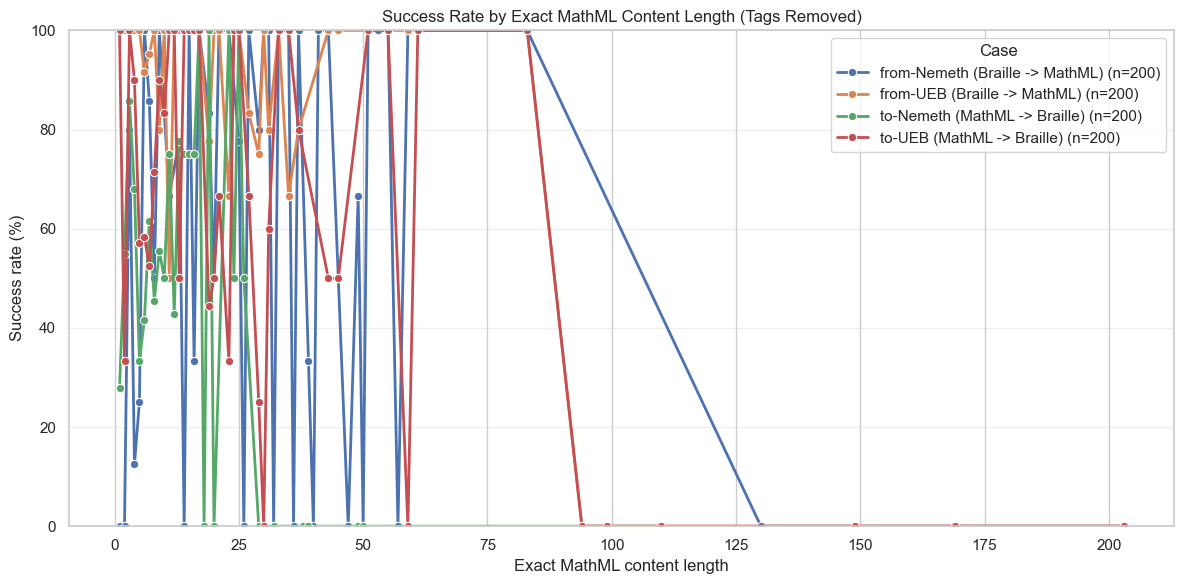

In [10]:
n_per_case = df.groupby("case").size().to_dict()
mathml_plot_df = mathml_length_summary.copy()
mathml_plot_df["case_label"] = mathml_plot_df["case"].map(lambda c: f"{c} (n={n_per_case[c]})")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=mathml_plot_df,
    x="mathml_content_length",
    y="success_rate_pct",
    hue="case_label",
    marker="o",
    linewidth=2,
    estimator=None,
    sort=True,
    ax=ax,
)

ax.set_title("Success Rate by Exact MathML Content Length (Tags Removed)")
ax.set_xlabel("Exact MathML content length")
ax.set_ylabel("Success rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.3)
ax.legend(title="Case")
fig.tight_layout()
plt.show()
